In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [ ]:
df.head()
df.isnull().sum()
df.describe()    
df.info()     

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

-------------------------------------------------------missing ---------------------------------------------------------------------------------------



In [4]:
categorical_col= df.select_dtypes(include = ["str"]).columns
numerical_col = df.select_dtypes(include = ["float64"]).columns

In [5]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy= "mean")
df[numerical_col]=num_imp.fit_transform(df[numerical_col])

cat_imp = SimpleImputer(strategy= "most_frequent")
df[categorical_col]=cat_imp.fit_transform(df[categorical_col])


In [6]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


----------------------------------------------------EDA (EXPLORATERY DATA ANALYSIS)------------------------------------------------------------

Text(0.5, 1.0, 'is loan approves or not')

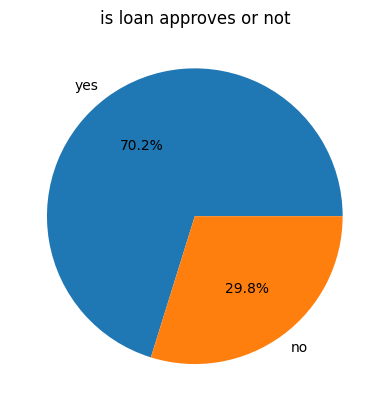

In [7]:
class_count=df["Loan_Approved"].value_counts()
plt.pie(class_count, labels = ["yes", "no"],autopct = "%1.1f%%")
plt.title("is loan approves or not")

Text(0.5, 1.0, 'is loan approves or not')

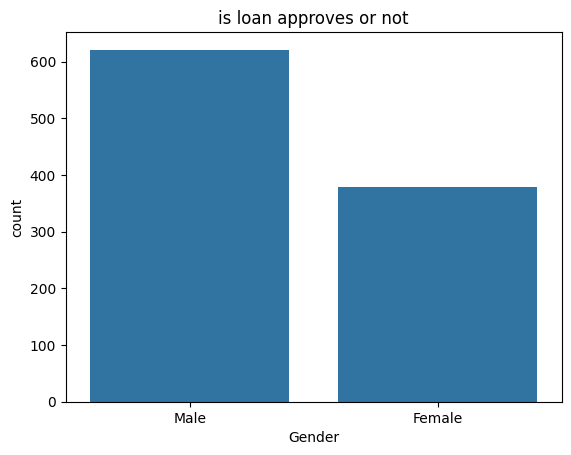

In [8]:
gender_count=df["Gender"].value_counts()
sns.barplot(gender_count)
plt.title("is loan approves or not")

<Axes: xlabel='Applicant_Income', ylabel='Count'>

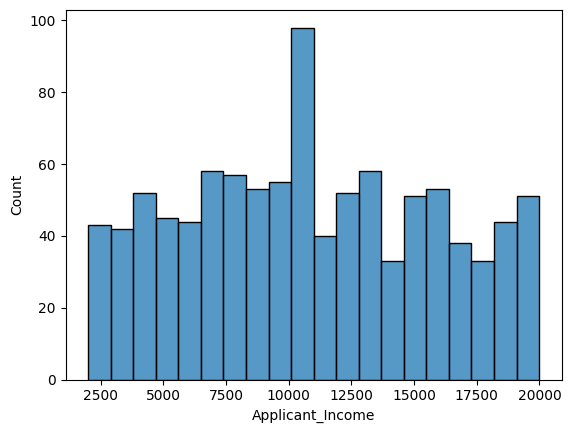

In [9]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

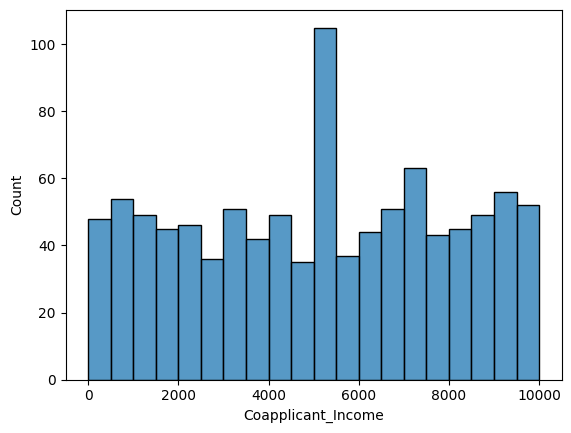

In [10]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

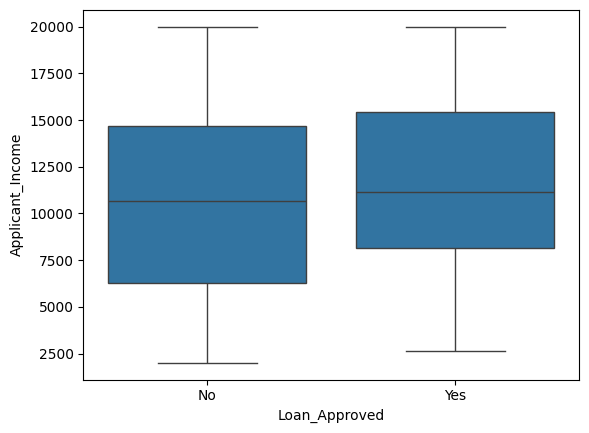

In [11]:
sns.boxplot(
    data = df,
    x= "Loan_Approved",
    y = "Applicant_Income"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

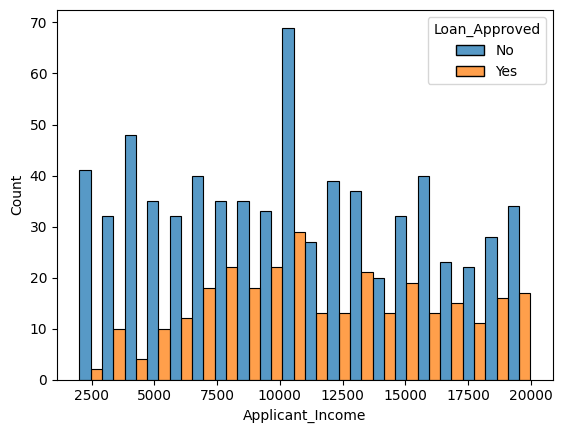

In [12]:
sns.histplot(
    data = df,
    x= "Applicant_Income",
    hue= "Loan_Approved",
    bins = 20,
    multiple= "dodge"
    
)

In [13]:
df=df.drop("Applicant_ID", axis=1)

In [14]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [15]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   int64  
 16  Gender            

In [17]:
    
cols =["Employment_Status", "Marital_Status","Loan_Purpose","Property_Area","Employer_Category","Gender"]

ohe = OneHotEncoder(drop= "first",handle_unknown="ignore", sparse_output=False)
encoded =ohe.fit_transform(df[cols])

encoded_df=pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols),index = df.index)
df = pd.concat([df.drop(columns=cols),encoded_df], axis=1)

In [18]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

In [20]:
num_col = df.select_dtypes(include= "number")
corr_matrix=num_col.corr()

num_col.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

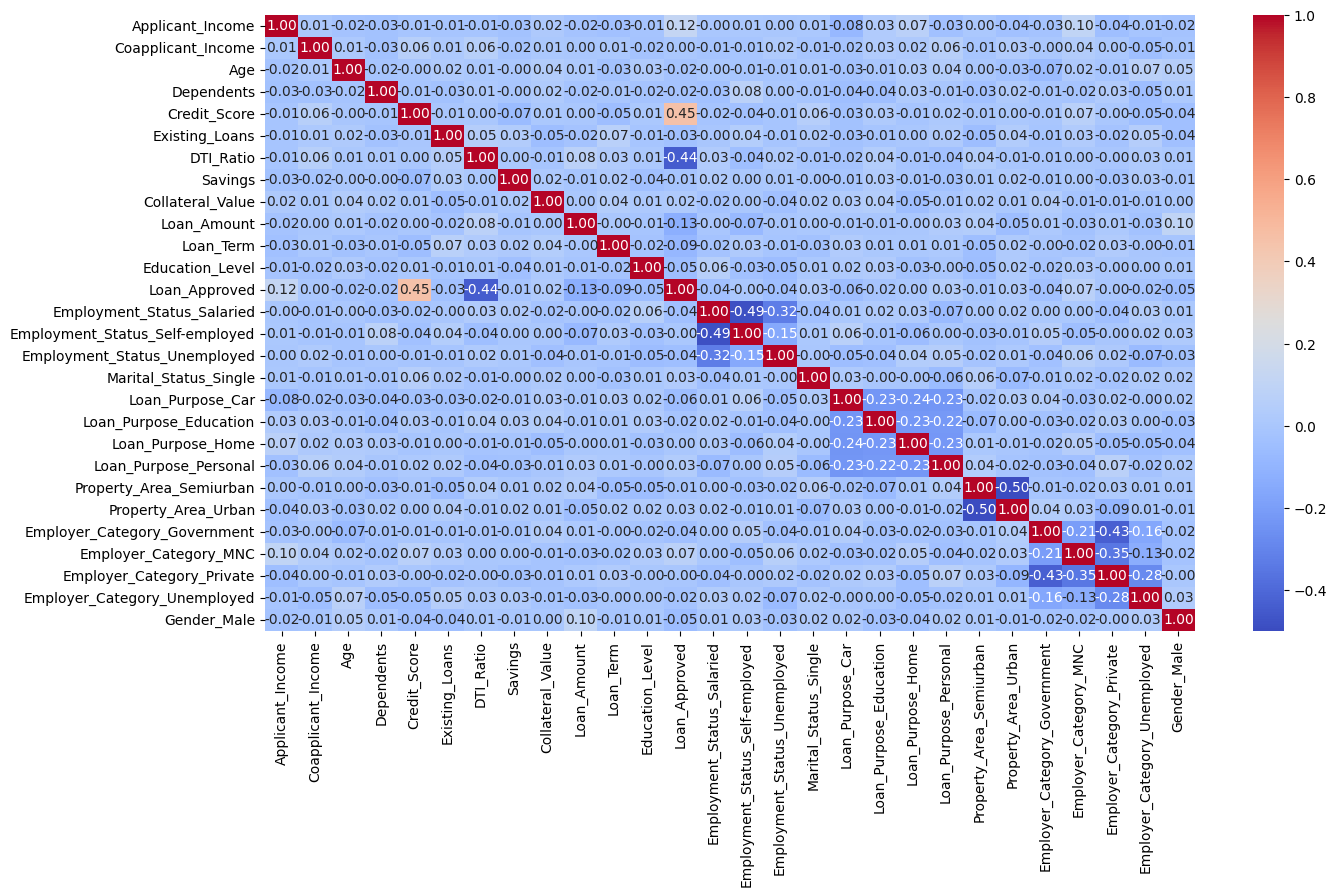

In [21]:
plt.figure(figsize=(15, 8))
sns. heatmap(
corr_matrix,
annot=True,
fmt=".2f",
cmap="coolwarm"

)

--------------------------------------------------------------train - test - split----------------------------------------------------------------

In [22]:
X= df.drop("Loan_Approved", axis= 1)
y = df["Loan_Approved"]

In [23]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
X_train_scale=scale.fit_transform(X_train)
X_test_scale=scale.transform(X_test)

----------------------------------------------#LogisticRegression--------------------------------------------------------------------------------------------

In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scale,y_train)
y_pred=log_model.predict(X_test_scale)


print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))

[[126  13]
 [ 14  47]]
accuracy_score 0.865
precision_score 0.7833333333333333
recall_score 0.7704918032786885
f1_score 0.7768595041322314


----------------------------------------------#KNN ALGORITHM--------------------------------------------------------------------------------------------

In [26]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors= 5)
model.fit(X_train_scale, y_train)
y_pred= model.predict(X_test_scale)

print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))                   

[[120  19]
 [ 29  32]]
accuracy_score 0.76
precision_score 0.6274509803921569
recall_score 0.5245901639344263
f1_score 0.5714285714285714


----------------------------------------------#NAIVE BAYSE--------------------------------------------------------------------------------------------

In [27]:
#naive bayse
from sklearn.naive_bayes import GaussianNB

nav_model = GaussianNB()
nav_model.fit(X_train_scale, y_train)
y_pred= nav_model.predict(X_test_scale)

print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))                 

[[128  11]
 [ 16  45]]
accuracy_score 0.865
precision_score 0.8035714285714286
recall_score 0.7377049180327869
f1_score 0.7692307692307693


# that final conculation the best model for that data is => naive bayse model

In [50]:
# Add or Tranform features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
df["Applicant_Income_log"] = np. log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio", "Applicant_Income"])
y = df ["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scale,y_train)
y_pred=log_model.predict(X_test_scale)



print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))

[[126  13]
 [ 14  47]]
accuracy_score 0.865
precision_score 0.7833333333333333
recall_score 0.7704918032786885
f1_score 0.7768595041322314


In [52]:
#knn
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors= 5)
model.fit(X_train_scale, y_train)
y_pred= model.predict(X_test_scale)

print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))                    

[[120  19]
 [ 29  32]]
accuracy_score 0.76
precision_score 0.6274509803921569
recall_score 0.5245901639344263
f1_score 0.5714285714285714


In [53]:
#naive bayse
from sklearn.naive_bayes import GaussianNB

nav_model = GaussianNB()
nav_model.fit(X_train_scale, y_train)
y_pred= nav_model.predict(X_test_scale)

 
print(confusion_matrix(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))                    

[[128  11]
 [ 16  45]]
accuracy_score 0.865
precision_score 0.8035714285714286
recall_score 0.7377049180327869
f1_score 0.7692307692307693
